<a href="https://colab.research.google.com/github/Danny-Shammas/mental-health-risk-nlp/blob/main/Mental_Health_Risk_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Mental Health Risk Detection — Final Project

**Course:** Neural Networks and Deep Learning  
**Dataset:** Reddit Mental Disorders (Kaggle)  
**Model:** DistilBERT (fine-tuned)

## ⚙️ Step 1 — Environment Setup

In [1]:
# Fix GitHub notebook rendering
import json, sys

In [ ]:
!pip install transformers accelerate kagglehub umap-learn -q

import torch
import gc
import os
import re
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU Memory: {total:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow.')

gc.collect()
torch.cuda.empty_cache()

SAVE_PATH = '/content/mental_health_project'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'Save path: {SAVE_PATH}')

GPU available: True
Device: Tesla T4
GPU Memory: 15.6 GB
Save path: /content/mental_health_project


## 📊 Step 2 — Data Loading & Exploration

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

print('Loading dataset from Kaggle...')
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kamaruladha/mental-disorders-identification-reddit-nlp",
    "mental_disorders_reddit.csv"
)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
print('Posts per subreddit (class):')
print(df['subreddit'].value_counts())

Loading dataset from Kaggle...


/tmp/ipykernel_1544/295376954.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 208M/208M [00:04<00:00, 52.9MB/s]

Extracting zip of mental_disorders_reddit.csv...


Dataset shape: (701787, 5)
Columns: ['title', 'selftext', 'created_utc', 'over_18', 'subreddit']

Posts per subreddit (class):
subreddit
BPD              241116
Anxiety          173990
depression       156972
mentalillness     53232
bipolar           51112
schizophrenia     25365
Name: count, dtype: int64


## 🧹 Step 3 — Text Cleaning & Class Balancing

> **Why clean?** Raw Reddit text contains URLs, user handles, HTML artifacts that add noise.
> **Why balance?** Equal samples per class prevents the model from being biased toward majority classes.

After cleaning: (604490, 9)
Sampling up to 80k per class...


/tmp/ipykernel_1544/2585485508.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(60000, len(x)), random_state=42))


Final sample shape: (282767, 9)
label
Anxiety          60000
BPD              60000
depression       60000
mentalillness    46261
bipolar          39939
schizophrenia    16567
Name: count, dtype: int64


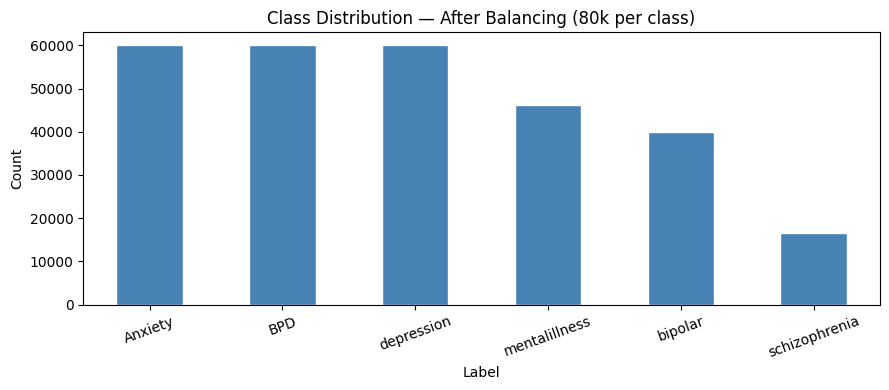

Original dataframe removed from memory.


In [ ]:
def clean_text(text):
    """Remove URLs, Reddit handles, HTML artifacts and extra whitespace."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+',         '', text)
    text = re.sub(r'u/\w+|r/\w+',            '', text)
    text = re.sub(r'&amp;|&lt;|&gt;|&nbsp;', '', text)
    text = re.sub(r'\s+',                    ' ', text)
    return text.strip()

# Fill missing values
df['selftext'] = df['selftext'].fillna('')
df['title']    = df['title'].fillna('')

# Combined text = title + body
df['text'] = (df['title'] + ' ' + df['selftext']).str.strip()

# Rename label column
df = df.rename(columns={'subreddit': 'label'})

# Remove deleted/empty posts
df = df[df['text'].str.len() > 5]
df = df[~df['text'].str.contains(r'\[deleted\]|\[removed\]', na=False)]

# Apply cleaning to all three text columns
df['clean_text']     = df['text'].apply(clean_text)
df['clean_title']    = df['title'].apply(clean_text)
df['clean_selftext'] = df['selftext'].apply(clean_text)

print(f'After cleaning: {df.shape}')

# Balanced sample — 80k per class
print('Sampling up to 80k per class...')
df_sample = (
    df.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=min(60000, len(x)), random_state=42))
    .reset_index(drop=True)
)
print(f'Final sample shape: {df_sample.shape}')
print(df_sample['label'].value_counts())

df_sample['label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white', figsize=(9, 4))
plt.title('Class Distribution — After Balancing (80k per class)')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

del df; gc.collect()
print('Original dataframe removed from memory.')

## ✂️ Step 4 — Train / Validation / Test Split

> - **80% Train** — used to train the model
> - **10% Validation** — used to monitor training and save best checkpoint
> - **10% Test** — used ONLY for final evaluation (never seen during training)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_sample['label_enc'] = le.fit_transform(df_sample['label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

train_df, temp_df = train_test_split(
    df_sample[['clean_text', 'clean_title', 'clean_selftext', 'label', 'label_enc']],
    test_size=0.2,
    stratify=df_sample['label_enc'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label_enc'],
    random_state=42
)

label_names = list(le.classes_)

for split in [train_df, val_df, test_df]:
    for col in ['clean_text', 'clean_title', 'clean_selftext']:
        split[col] = split[col].fillna('').astype(str)

print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')
print(f'Test  : {len(test_df):,}')
print(f'Labels: {label_names}')

del df_sample, temp_df; gc.collect()

Label mapping: {'Anxiety': np.int64(0), 'BPD': np.int64(1), 'bipolar': np.int64(2), 'depression': np.int64(3), 'mentalillness': np.int64(4), 'schizophrenia': np.int64(5)}
Train : 226,213
Val   : 28,277
Test  : 28,277
Labels: ['Anxiety', 'BPD', 'bipolar', 'depression', 'mentalillness', 'schizophrenia']


0

## 🔤 Step 5 — Tokenization & Dataset Class

> DistilBERT requires tokenized input — sequences of integers, not raw text.
> The tokenizer splits words into subword pieces and adds special [CLS] and [SEP] tokens.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print('Tokenizer vocab size:', tokenizer.vocab_size)

class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Build dataloaders using COMBINED text (title + body)
train_dataset = MentalHealthDataset(train_df['clean_text'], train_df['label_enc'], tokenizer)
val_dataset   = MentalHealthDataset(val_df['clean_text'],   val_df['label_enc'],   tokenizer)
test_dataset  = MentalHealthDataset(test_df['clean_text'],  test_df['label_enc'],  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train batches: {len(train_loader):,}')
print(f'Val batches  : {len(val_loader):,}')
print(f'Test batches : {len(test_loader):,}')

secs_per_batch = 0.18
mins_per_epoch = (len(train_loader) * secs_per_batch) / 60
print(f'\nEstimated time per epoch  : ~{mins_per_epoch:.0f} minutes')
print(f'Estimated total (5 epochs): ~{mins_per_epoch*5:.0f} minutes')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 30522
Train batches: 7,070
Val batches  : 884
Test batches : 884

Estimated time per epoch  : ~21 minutes
Estimated total (5 epochs): ~106 minutes


## 🤖 Step 6 — DistilBERT Model, Optimizer & Scheduler

> DistilBERT is a compressed version of BERT — 40% smaller, 60% faster, retains 97% of BERT's performance.
> We fine-tune it on our Reddit dataset by adding a classification head on top.

In [ ]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

NUM_CLASSES = len(le.classes_)
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_CLASSES
)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

EPOCHS    = 4
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
print(f'\nTotal training steps: {total_steps:,}')
print(f'Warmup steps        : {total_steps // 10:,}')
print(f'Epochs              : {EPOCHS}')
print(f'Learning rate       : 1e-5')

Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,958,086
Trainable parameters: 66,958,086

Total training steps: 28,280
Warmup steps        : 2,828
Epochs              : 4
Learning rate       : 1e-5


## 🏋️ Step 7 — Training DistilBERT

> The training loop iterates over the dataset for EPOCHS epochs.
> The best model checkpoint (highest val accuracy) is saved automatically.

In [ ]:
from sklearn.metrics import accuracy_score

def train_epoch(model, loader, optimizer, scheduler, device, epoch_num):
    model.train()
    total_loss, correct = 0, 0
    start = time.time()

    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()

        if i % 500 == 0:
            elapsed   = (time.time() - start) / 60
            remaining = (elapsed / (i + 1)) * (len(loader) - i)
            print(f'  Epoch {epoch_num} | Batch {i:>5}/{len(loader):>5} | '
                  f'Loss: {loss.item():.4f} | Elapsed: {elapsed:.1f}m | Remaining: {remaining:.1f}m')

        if i % 100 == 0:
            torch.cuda.empty_cache()

    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            preds          = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    torch.cuda.empty_cache()
    return all_preds, all_labels


# ── Main training loop ────────────────────────────────────────
best_val_acc = 0
training_log = []
total_start  = time.time()

print('=' * 55)
print(f'DistilBERT Training — {len(train_df):,} posts')
print(f'Epochs: {EPOCHS} | Batch: 32 | LR: 1e-5 | Device: {device}')
print('=' * 55)

for epoch in range(EPOCHS):
    print(f'\n{"="*55}')
    print(f'EPOCH {epoch+1}/{EPOCHS}')
    print(f'{"="*55}')

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device, epoch+1)
    val_preds, val_labels = evaluate(model, val_loader, device)
    val_acc = accuracy_score(val_labels, val_preds)

    training_log.append({
        'epoch': epoch+1, 'train_loss': round(train_loss, 4),
        'train_acc': round(train_acc, 4), 'val_acc': round(val_acc, 4)
    })

    elapsed_total = (time.time() - total_start) / 3600
    print(f'\nTrain Loss : {train_loss:.4f}')
    print(f'Train Acc  : {train_acc:.4f}')
    print(f'Val Acc    : {val_acc:.4f}')
    print(f'Total time : {elapsed_total:.2f}h')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(f'{SAVE_PATH}/best_model')
        tokenizer.save_pretrained(f'{SAVE_PATH}/best_model')
        print(f'  ✅ New best model saved (Val Acc={best_val_acc:.4f})')
    else:
        print(f'  No improvement. Best so far: {best_val_acc:.4f}')

total_time = (time.time() - total_start) / 3600
print(f'\n✅ Training complete in {total_time:.2f}h')
print(f'Best Val Accuracy: {best_val_acc:.4f}')

DistilBERT Training — 226,213 posts
Epochs: 4 | Batch: 32 | LR: 1e-5 | Device: cuda

EPOCH 1/4
  Epoch 1 | Batch     0/ 7070 | Loss: 1.8209 | Elapsed: 0.0m | Remaining: 193.2m
  Epoch 1 | Batch   500/ 7070 | Loss: 1.6339 | Elapsed: 3.0m | Remaining: 39.3m
  Epoch 1 | Batch  1000/ 7070 | Loss: 1.0833 | Elapsed: 6.1m | Remaining: 36.7m
  Epoch 1 | Batch  1500/ 7070 | Loss: 0.9301 | Elapsed: 9.1m | Remaining: 33.8m
  Epoch 1 | Batch  2000/ 7070 | Loss: 0.6125 | Elapsed: 12.1m | Remaining: 30.8m
  Epoch 1 | Batch  2500/ 7070 | Loss: 0.4634 | Elapsed: 15.2m | Remaining: 27.8m
  Epoch 1 | Batch  3000/ 7070 | Loss: 0.8550 | Elapsed: 18.2m | Remaining: 24.7m
  Epoch 1 | Batch  3500/ 7070 | Loss: 0.6550 | Elapsed: 21.3m | Remaining: 21.7m
  Epoch 1 | Batch  4000/ 7070 | Loss: 0.8216 | Elapsed: 24.3m | Remaining: 18.6m
  Epoch 1 | Batch  4500/ 7070 | Loss: 0.8013 | Elapsed: 27.3m | Remaining: 15.6m
  Epoch 1 | Batch  5000/ 7070 | Loss: 0.6231 | Elapsed: 30.4m | Remaining: 12.6m
  Epoch 1 | Batch

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ New best model saved (Val Acc=0.7235)

EPOCH 2/4
  Epoch 2 | Batch     0/ 7070 | Loss: 0.6830 | Elapsed: 0.0m | Remaining: 51.3m
  Epoch 2 | Batch   500/ 7070 | Loss: 0.8752 | Elapsed: 3.0m | Remaining: 40.0m
  Epoch 2 | Batch  1000/ 7070 | Loss: 0.6898 | Elapsed: 6.1m | Remaining: 36.9m
  Epoch 2 | Batch  1500/ 7070 | Loss: 1.0728 | Elapsed: 9.1m | Remaining: 33.9m
  Epoch 2 | Batch  2000/ 7070 | Loss: 0.7621 | Elapsed: 12.2m | Remaining: 30.8m
  Epoch 2 | Batch  2500/ 7070 | Loss: 0.6243 | Elapsed: 15.2m | Remaining: 27.8m
  Epoch 2 | Batch  3000/ 7070 | Loss: 0.8164 | Elapsed: 18.2m | Remaining: 24.7m
  Epoch 2 | Batch  3500/ 7070 | Loss: 0.9811 | Elapsed: 21.3m | Remaining: 21.7m
  Epoch 2 | Batch  4000/ 7070 | Loss: 0.6573 | Elapsed: 24.3m | Remaining: 18.6m
  Epoch 2 | Batch  4500/ 7070 | Loss: 0.6438 | Elapsed: 27.3m | Remaining: 15.6m
  Epoch 2 | Batch  5000/ 7070 | Loss: 0.4388 | Elapsed: 30.4m | Remaining: 12.6m
  Epoch 2 | Batch  5500/ 7070 | Loss: 1.0157 | Elapsed: 33.4

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ New best model saved (Val Acc=0.7340)

EPOCH 3/4
  Epoch 3 | Batch     0/ 7070 | Loss: 0.7284 | Elapsed: 0.0m | Remaining: 54.5m
  Epoch 3 | Batch   500/ 7070 | Loss: 0.9302 | Elapsed: 3.1m | Remaining: 40.8m
  Epoch 3 | Batch  1000/ 7070 | Loss: 0.8553 | Elapsed: 6.2m | Remaining: 37.6m
  Epoch 3 | Batch  1500/ 7070 | Loss: 0.7590 | Elapsed: 9.2m | Remaining: 34.3m
  Epoch 3 | Batch  2000/ 7070 | Loss: 0.7935 | Elapsed: 12.3m | Remaining: 31.1m
  Epoch 3 | Batch  2500/ 7070 | Loss: 0.4617 | Elapsed: 15.3m | Remaining: 28.0m
  Epoch 3 | Batch  3000/ 7070 | Loss: 0.6101 | Elapsed: 18.3m | Remaining: 24.9m
  Epoch 3 | Batch  3500/ 7070 | Loss: 0.9664 | Elapsed: 21.4m | Remaining: 21.8m
  Epoch 3 | Batch  4000/ 7070 | Loss: 0.9222 | Elapsed: 24.4m | Remaining: 18.7m
  Epoch 3 | Batch  4500/ 7070 | Loss: 0.5820 | Elapsed: 27.4m | Remaining: 15.7m
  Epoch 3 | Batch  5000/ 7070 | Loss: 0.7795 | Elapsed: 30.5m | Remaining: 12.6m
  Epoch 3 | Batch  5500/ 7070 | Loss: 0.8163 | Elapsed: 33.5

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ New best model saved (Val Acc=0.7385)

EPOCH 4/4
  Epoch 4 | Batch     0/ 7070 | Loss: 0.3979 | Elapsed: 0.0m | Remaining: 49.4m
  Epoch 4 | Batch   500/ 7070 | Loss: 0.7481 | Elapsed: 3.0m | Remaining: 39.9m
  Epoch 4 | Batch  1000/ 7070 | Loss: 0.6351 | Elapsed: 6.1m | Remaining: 36.9m
  Epoch 4 | Batch  1500/ 7070 | Loss: 0.5402 | Elapsed: 9.1m | Remaining: 33.9m
  Epoch 4 | Batch  2000/ 7070 | Loss: 0.6560 | Elapsed: 12.2m | Remaining: 30.8m
  Epoch 4 | Batch  2500/ 7070 | Loss: 0.5201 | Elapsed: 15.2m | Remaining: 27.8m
  Epoch 4 | Batch  3000/ 7070 | Loss: 1.0677 | Elapsed: 18.2m | Remaining: 24.7m
  Epoch 4 | Batch  3500/ 7070 | Loss: 0.7055 | Elapsed: 21.2m | Remaining: 21.7m
  Epoch 4 | Batch  4000/ 7070 | Loss: 0.9006 | Elapsed: 24.3m | Remaining: 18.6m
  Epoch 4 | Batch  4500/ 7070 | Loss: 0.7157 | Elapsed: 27.3m | Remaining: 15.6m
  Epoch 4 | Batch  5000/ 7070 | Loss: 0.7199 | Elapsed: 30.3m | Remaining: 12.6m
  Epoch 4 | Batch  5500/ 7070 | Loss: 1.0799 | Elapsed: 33.4

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ New best model saved (Val Acc=0.7386)

✅ Training complete in 3.00h
Best Val Accuracy: 0.7386


## 📈 Step 8 — Learning Curves

> Shows how the model improved over epochs.
> If val accuracy keeps going up → model is still learning. If it drops → overfitting.

Learning curves saved: /content/mental_health_project/learning_curves.png


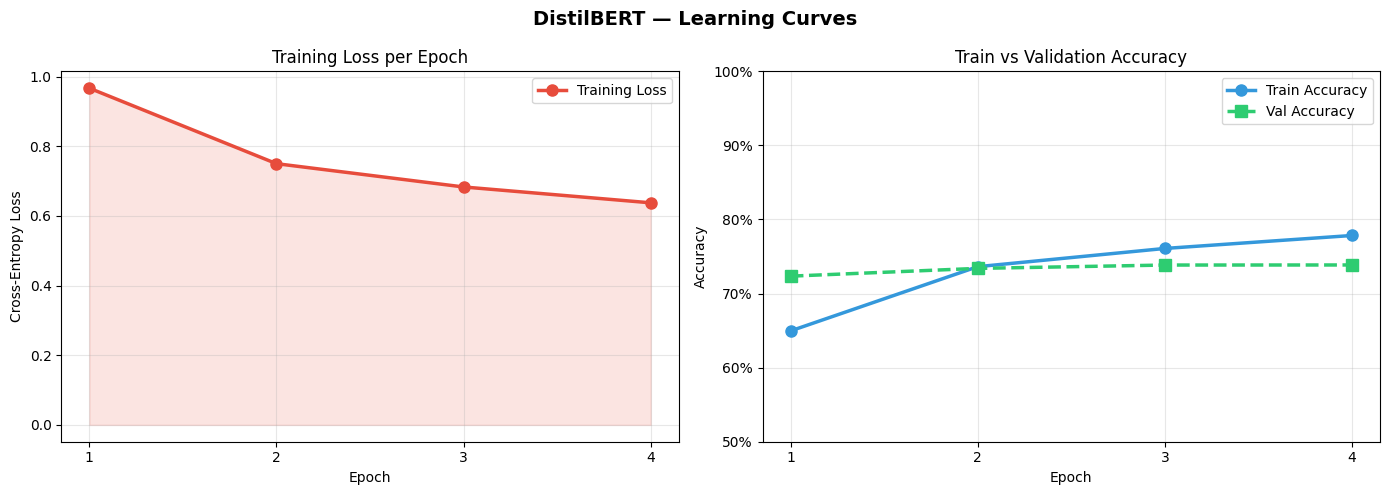


Metrics per epoch:
Epoch    Train Loss   Train Acc    Val Acc      Improvement
------------------------------------------------------------
  1      0.9669       0.6496       0.7235       —
  2      0.7501       0.7363       0.7340       +0.0105
  3      0.6832       0.7609       0.7385       +0.0045
  4      0.6377       0.7784       0.7386       +0.0001


In [ ]:
def plot_learning_curves(training_log, save_path=None):
    epochs     = [e['epoch']      for e in training_log]
    train_loss = [e['train_loss'] for e in training_log]
    train_acc  = [e['train_acc']  for e in training_log]
    val_acc    = [e['val_acc']    for e in training_log]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('DistilBERT — Learning Curves', fontsize=14, fontweight='bold')

    ax1 = axes[0]
    ax1.plot(epochs, train_loss, 'o-', color='#e74c3c', linewidth=2.5, markersize=8, label='Training Loss')
    ax1.fill_between(epochs, train_loss, alpha=0.15, color='#e74c3c')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title('Training Loss per Epoch')
    ax1.legend(); ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(epochs, train_acc, 'o-', color='#3498db', linewidth=2.5, markersize=8, label='Train Accuracy')
    ax2.plot(epochs, val_acc,   's--', color='#2ecc71', linewidth=2.5, markersize=8, label='Val Accuracy')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Train vs Validation Accuracy')
    ax2.legend(); ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax2.grid(True, alpha=0.3); ax2.set_ylim(0.5, 1.0)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Learning curves saved: {save_path}')
    plt.show()

    print('\nMetrics per epoch:')
    print(f'{"Epoch":<8} {"Train Loss":<12} {"Train Acc":<12} {"Val Acc":<12} {"Improvement"}')
    print('-' * 60)
    for i, e in enumerate(training_log):
        delta = f'+{e["val_acc"] - training_log[i-1]["val_acc"]:.4f}' if i > 0 else '—'
        print(f'  {e["epoch"]:<6} {e["train_loss"]:<12.4f} {e["train_acc"]:<12.4f} {e["val_acc"]:<12.4f} {delta}')

plot_learning_curves(training_log, save_path=f'{SAVE_PATH}/learning_curves.png')

## 📏 Step 9 — Baseline: TF-IDF + Logistic Regression

> We now compare DistilBERT against a simple baseline.
> TF-IDF counts word frequencies. Logistic Regression classifies based on those counts.
> This tells us: **how much did DistilBERT actually improve over a simple approach?**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print('=' * 55)
print('BASELINE: TF-IDF + Logistic Regression')
print('=' * 55)

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode',
    analyzer='word'
)

print('Fitting TF-IDF...')
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_val_tfidf   = tfidf.transform(val_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])
print(f'Feature matrix shape: {X_train_tfidf.shape}')

print('\nTraining Logistic Regression...')
start = time.time()
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='saga', n_jobs=-1, random_state=42)
lr_model.fit(X_train_tfidf, train_df['label_enc'])
train_time = time.time() - start
print(f'Training time: {train_time:.1f}s')

val_preds_lr  = lr_model.predict(X_val_tfidf)
test_preds_lr = lr_model.predict(X_test_tfidf)
val_acc_lr    = accuracy_score(val_df['label_enc'],  val_preds_lr)
test_acc_lr   = accuracy_score(test_df['label_enc'], test_preds_lr)

print(f'\nBaseline Val Accuracy : {val_acc_lr:.4f} ({val_acc_lr*100:.1f}%)')
print(f'Baseline Test Accuracy: {test_acc_lr:.4f} ({test_acc_lr*100:.1f}%)')
print('\nClassification Report (Baseline):')
print(classification_report(test_df['label_enc'], test_preds_lr, target_names=label_names))

baseline_results = {
    'model': 'TF-IDF + Logistic Regression',
    'val_acc':  round(val_acc_lr, 4),
    'test_acc': round(test_acc_lr, 4),
}

# Compare with DistilBERT
best_distilbert = max(training_log, key=lambda x: x['val_acc'])
improvement = best_distilbert['val_acc'] - baseline_results['val_acc']
print('\n' + '=' * 55)
print('MODEL COMPARISON')
print('=' * 55)
print(f'  TF-IDF + LR : Val {baseline_results["val_acc"]:.4f} | Test {baseline_results["test_acc"]:.4f}')
print(f'  DistilBERT  : Val {best_distilbert["val_acc"]:.4f}')
print(f'  Improvement : +{improvement:.4f} ({improvement*100:.1f} percentage points)')

BASELINE: TF-IDF + Logistic Regression
Fitting TF-IDF...
Feature matrix shape: (226213, 50000)

Training Logistic Regression...
Training time: 38.4s

Baseline Val Accuracy : 0.7193 (71.9%)
Baseline Test Accuracy: 0.7219 (72.2%)

Classification Report (Baseline):
               precision    recall  f1-score   support

      Anxiety       0.80      0.82      0.81      6000
          BPD       0.78      0.78      0.78      6000
      bipolar       0.76      0.70      0.73      3994
   depression       0.67      0.79      0.73      6000
mentalillness       0.56      0.52      0.54      4626
schizophrenia       0.74      0.54      0.63      1657

     accuracy                           0.72     28277
    macro avg       0.72      0.69      0.70     28277
 weighted avg       0.72      0.72      0.72     28277


MODEL COMPARISON
  TF-IDF + LR : Val 0.7193 | Test 0.7219
  DistilBERT  : Val 0.7386
  Improvement : +0.0193 (1.9 percentage points)


## 🔬 Step 10 — Experiment A: Title vs Body vs Combined

> We use the **already trained DistilBERT model** and run predictions 3 times:
> - Once on title only
> - Once on body (selftext) only
> - Once on combined (title + body) — this is what we trained on
>
> This tells us: which input gives the model the most useful information?

In [ ]:
from sklearn.metrics import accuracy_score

print('=' * 60)
print('EXPERIMENT A: TITLE vs SELFTEXT vs COMBINED')
print('Using the trained DistilBERT model — no retraining needed')
print('=' * 60)

# Load best model
best_model = DistilBertForSequenceClassification.from_pretrained(f'{SAVE_PATH}/best_model')
best_model.to(device)
best_model.eval()

def evaluate_on_text(model, texts, labels, tokenizer, device, desc=''):
    """Run inference on given texts using the trained model."""
    dataset = MentalHealthDataset(texts, labels, tokenizer)
    loader  = DataLoader(dataset, batch_size=32, shuffle=False)
    preds, trues = evaluate(model, loader, device)
    acc = accuracy_score(trues, preds)
    print(f'  {desc:<30} Accuracy: {acc:.4f} ({acc*100:.1f}%)')
    return acc, preds, trues

print()
acc_title, preds_title, _ = evaluate_on_text(
    best_model, test_df['clean_title'],    test_df['label_enc'], tokenizer, device, 'Title only')

acc_body, preds_body, _ = evaluate_on_text(
    best_model, test_df['clean_selftext'], test_df['label_enc'], tokenizer, device, 'Body (selftext) only')

acc_combined, preds_combined, trues_combined = evaluate_on_text(
    best_model, test_df['clean_text'],     test_df['label_enc'], tokenizer, device, 'Combined (title + body)')

# Summary
print()
print('=' * 60)
print(f'  {"Input":<30} {"Accuracy":>10}')
print('-' * 42)
results_exp_a = {
    'Title only':    acc_title,
    'Body only':     acc_body,
    'Combined':      acc_combined,
}
best_input = max(results_exp_a, key=results_exp_a.get)
for name, acc in results_exp_a.items():
    marker = ' ← BEST' if name == best_input else ''
    print(f'  {name:<30} {acc:>10.4f}{marker}')
print('=' * 60)
print(f'\n✅ Conclusion: "{best_input}" gives the best results.')
print(f'   This means the model benefits most from this input type.')

EXPERIMENT A: TITLE vs SELFTEXT vs COMBINED
Using the trained DistilBERT model — no retraining needed


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  Title only                     Accuracy: 0.4462 (44.6%)
  Body (selftext) only           Accuracy: 0.6626 (66.3%)
  Combined (title + body)        Accuracy: 0.7397 (74.0%)

  Input                            Accuracy
------------------------------------------
  Title only                         0.4462
  Body only                          0.6626
  Combined                           0.7397 ← BEST

✅ Conclusion: "Combined" gives the best results.
   This means the model benefits most from this input type.


## 🗂️ Step 11 — Experiment B: Concept Clustering (K-Means + UMAP)

> We extract the internal representations (embeddings) from the trained DistilBERT model.
> These 768-dimensional vectors capture what the model learned about each post.
> K-Means groups similar posts. UMAP visualizes them in 2D.
> This shows us: **what patterns did the model learn to separate mental health conditions?**

Extracting DistilBERT embeddings (CLS token) from trained model...
Using 1000 samples per class for speed...
Clustering sample: 6000 posts


/tmp/ipykernel_1544/982238003.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(1000, len(x)), random_state=42))


  Processed 0/6000 posts...
Embeddings shape: (6000, 768)

Running K-Means clustering...

Cluster → Label distribution:
label    Anxiety  BPD  bipolar  depression  mentalillness  schizophrenia
cluster                                                                 
0            867   17       19          17             77             11
1              4    4       57           2             52            777
2             61  163       80         913            211             26
3              1   18      710          11             36             34
4              9  697       23           6             35              4
5             58  101      111          51            589            148

Running UMAP dimensionality reduction (~1-2 min)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


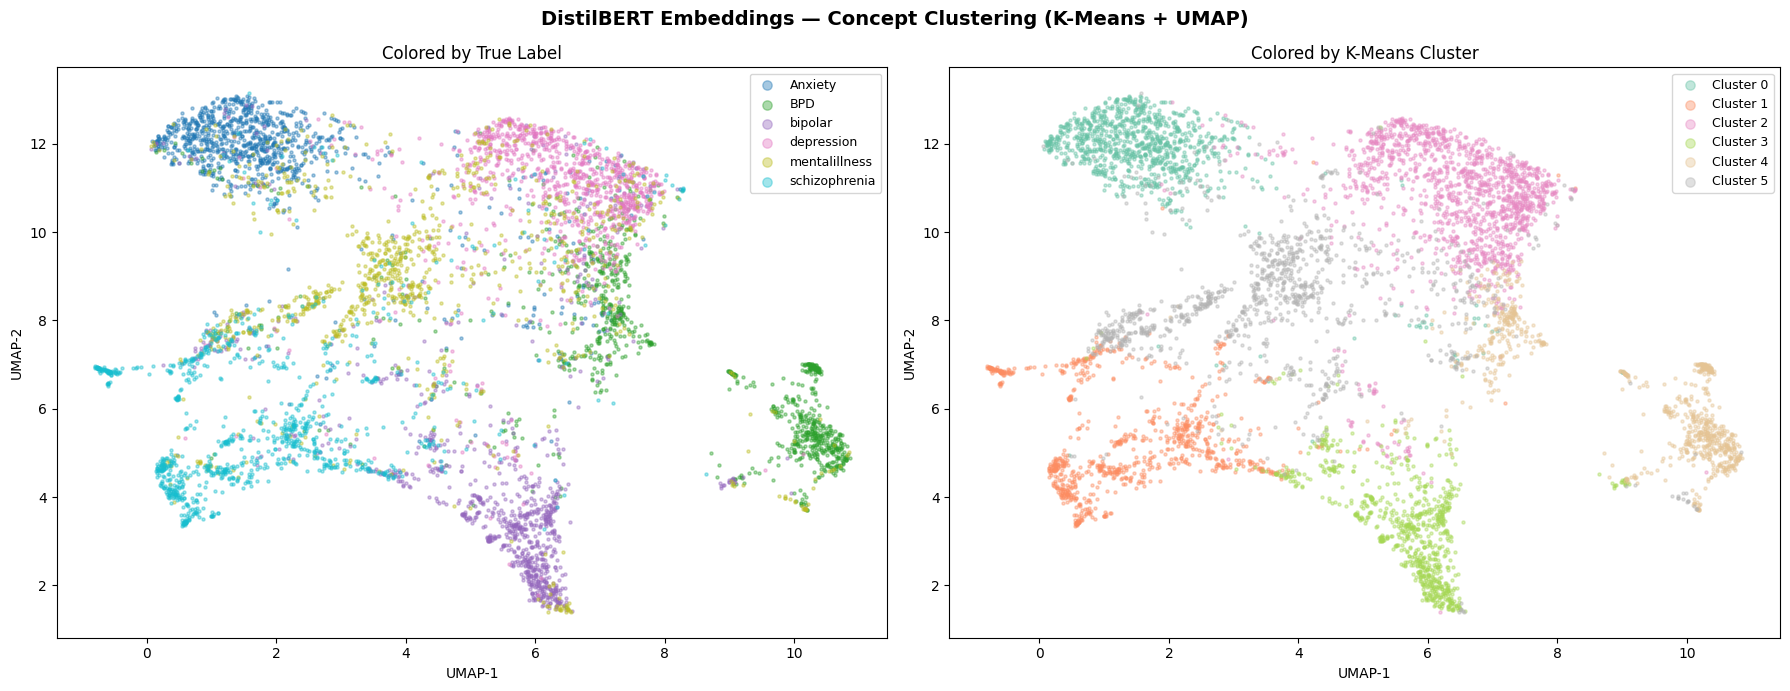

UMAP plot saved.


In [ ]:
import umap
from sklearn.cluster import KMeans

print('Extracting DistilBERT embeddings (CLS token) from trained model...')
print('Using 1000 samples per class for speed...')

# Subsample for speed
cluster_df = (
    pd.concat([train_df, val_df, test_df])
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=min(1000, len(x)), random_state=42))
    .reset_index(drop=True)
)
print(f'Clustering sample: {len(cluster_df)} posts')

# Extract CLS embeddings from DistilBERT
def get_embeddings(texts, model, tokenizer, device, batch_size=64):
    model.eval()
    all_embeddings = []
    texts = texts.reset_index(drop=True)
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size].tolist()
        enc = tokenizer(batch_texts, max_length=128, padding='max_length',
                        truncation=True, return_tensors='pt')
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            outputs = model.distilbert(input_ids=input_ids, attention_mask=attention_mask)
            cls_emb = outputs.last_hidden_state[:, 0, :]  # CLS token
        all_embeddings.append(cls_emb.cpu().numpy())
        if i % 1000 == 0:
            print(f'  Processed {i}/{len(texts)} posts...')
    return np.vstack(all_embeddings)

embeddings = get_embeddings(cluster_df['clean_text'], best_model, tokenizer, device)
print(f'Embeddings shape: {embeddings.shape}')

# K-Means clustering on DistilBERT embeddings
print('\nRunning K-Means clustering...')
n_clusters = len(label_names)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(embeddings)

print('\nCluster → Label distribution:')
print(pd.crosstab(cluster_df['cluster'], cluster_df['label']))

# UMAP visualization
print('\nRunning UMAP dimensionality reduction (~1-2 min)...')
reducer   = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(embeddings)

label_list     = sorted(cluster_df['label'].unique())
colors         = plt.cm.tab10(np.linspace(0, 1, len(label_list)))
label_to_color = {l: c for l, c in zip(label_list, colors)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('DistilBERT Embeddings — Concept Clustering (K-Means + UMAP)', fontsize=14, fontweight='bold')

ax1 = axes[0]
for label in label_list:
    mask = cluster_df['label'] == label
    ax1.scatter(embedding[mask, 0], embedding[mask, 1],
                c=[label_to_color[label]], label=label, alpha=0.4, s=5)
ax1.set_title('Colored by True Label')
ax1.legend(markerscale=3, fontsize=9)
ax1.set_xlabel('UMAP-1'); ax1.set_ylabel('UMAP-2')

ax2 = axes[1]
cluster_colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))
for i in range(n_clusters):
    mask = cluster_df['cluster'] == i
    ax2.scatter(embedding[mask, 0], embedding[mask, 1],
                c=[cluster_colors[i]], label=f'Cluster {i}', alpha=0.4, s=5)
ax2.set_title('Colored by K-Means Cluster')
ax2.legend(markerscale=3, fontsize=9)
ax2.set_xlabel('UMAP-1'); ax2.set_ylabel('UMAP-2')

plt.tight_layout()
fig.savefig(f'{SAVE_PATH}/clustering_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('UMAP plot saved.')

## 📊 Step 12 — Final Evaluation: Confusion Matrix & Classification Report

> We evaluate the best saved checkpoint on the held-out test set.
> The confusion matrix shows which classes are confused with each other.

Final Test Results:

               precision    recall  f1-score   support

      Anxiety       0.81      0.84      0.82      6000
          BPD       0.78      0.78      0.78      6000
      bipolar       0.78      0.72      0.75      3994
   depression       0.71      0.78      0.74      6000
mentalillness       0.61      0.55      0.58      4626
schizophrenia       0.69      0.67      0.68      1657

     accuracy                           0.74     28277
    macro avg       0.73      0.72      0.73     28277
 weighted avg       0.74      0.74      0.74     28277



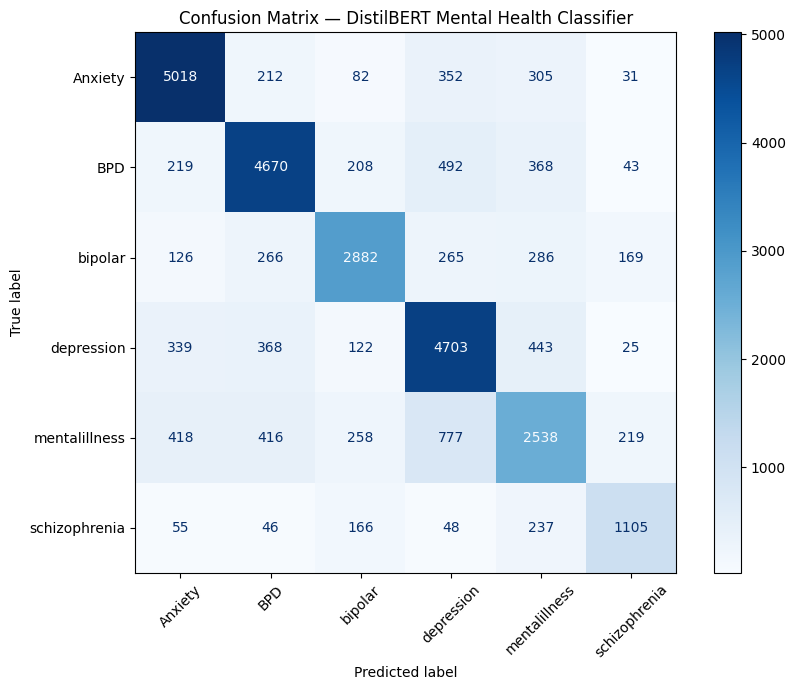

Confusion matrix saved.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_preds, test_labels = evaluate(best_model, test_loader, device)

print('Final Test Results:\n')
print(classification_report(test_labels, test_preds, target_names=label_names))

cm  = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
    xticks_rotation=45, cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — DistilBERT Mental Health Classifier')
plt.tight_layout()
fig.savefig(f'{SAVE_PATH}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

## 🔮 Step 13 — Prediction on New Examples

> We test the trained model on new text inputs that were never part of the dataset.

In [ ]:
def predict(text, model, tokenizer, device, label_encoder):
    model.eval()
    clean = clean_text(text)
    enc   = tokenizer(clean, return_tensors='pt', max_length=128,
                      padding='max_length', truncation=True)
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

    probs      = torch.softmax(logits, dim=1).squeeze()
    pred_idx   = probs.argmax().item()
    confidence = probs[pred_idx].item()
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    print(f'\nInput      : {text[:80]}')
    print(f'Prediction : {pred_label.upper()} ({confidence*100:.1f}% confidence)')
    print('All probabilities:')
    for i, p in enumerate(probs):
        label = label_encoder.inverse_transform([i])[0]
        bar   = '█' * int(p.item() * 40)
        print(f'  {label:<20} {p.item()*100:5.1f}%  {bar}')
    return pred_label, confidence

test_texts = [
    "I haven't left my room in 3 days. Everything feels pointless and empty.",
    "My thoughts are racing so fast I can't sleep. Heart is pounding for no reason.",
    "I keep hearing voices that tell me things others can't hear.",
    "My mood swings are extreme. One day I'm on top of the world, next I crash.",
    "I just feel lost. I don't know what's wrong with me anymore."
]

print('=' * 60)
print('PREDICTION ON NEW EXAMPLES')
print('=' * 60)
for text in test_texts:
    predict(text, best_model, tokenizer, device, le)
    print('-' * 55)

PREDICTION ON NEW EXAMPLES

Input      : I haven't left my room in 3 days. Everything feels pointless and empty.
Prediction : DEPRESSION (72.0% confidence)
All probabilities:
  Anxiety                2.7%  █
  BPD                    9.9%  ███
  bipolar                3.4%  █
  depression            72.0%  ████████████████████████████
  mentalillness         10.4%  ████
  schizophrenia          1.6%  
-------------------------------------------------------

Input      : My thoughts are racing so fast I can't sleep. Heart is pounding for no reason.
Prediction : ANXIETY (76.8% confidence)
All probabilities:
  Anxiety               76.8%  ██████████████████████████████
  BPD                    1.1%  
  bipolar                9.6%  ███
  depression             2.4%  
  mentalillness          8.0%  ███
  schizophrenia          2.1%  
-------------------------------------------------------

Input      : I keep hearing voices that tell me things others can't hear.
Prediction : MENTALILLNESS (6

## 🔍 Step 14 — Attention Visualization (Explainable AI)

> Shows WHICH words the model focused on when making a prediction.
> This is important for explainability — we can see if the model is paying attention to the right words.

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Best model loaded with eager attention backend.


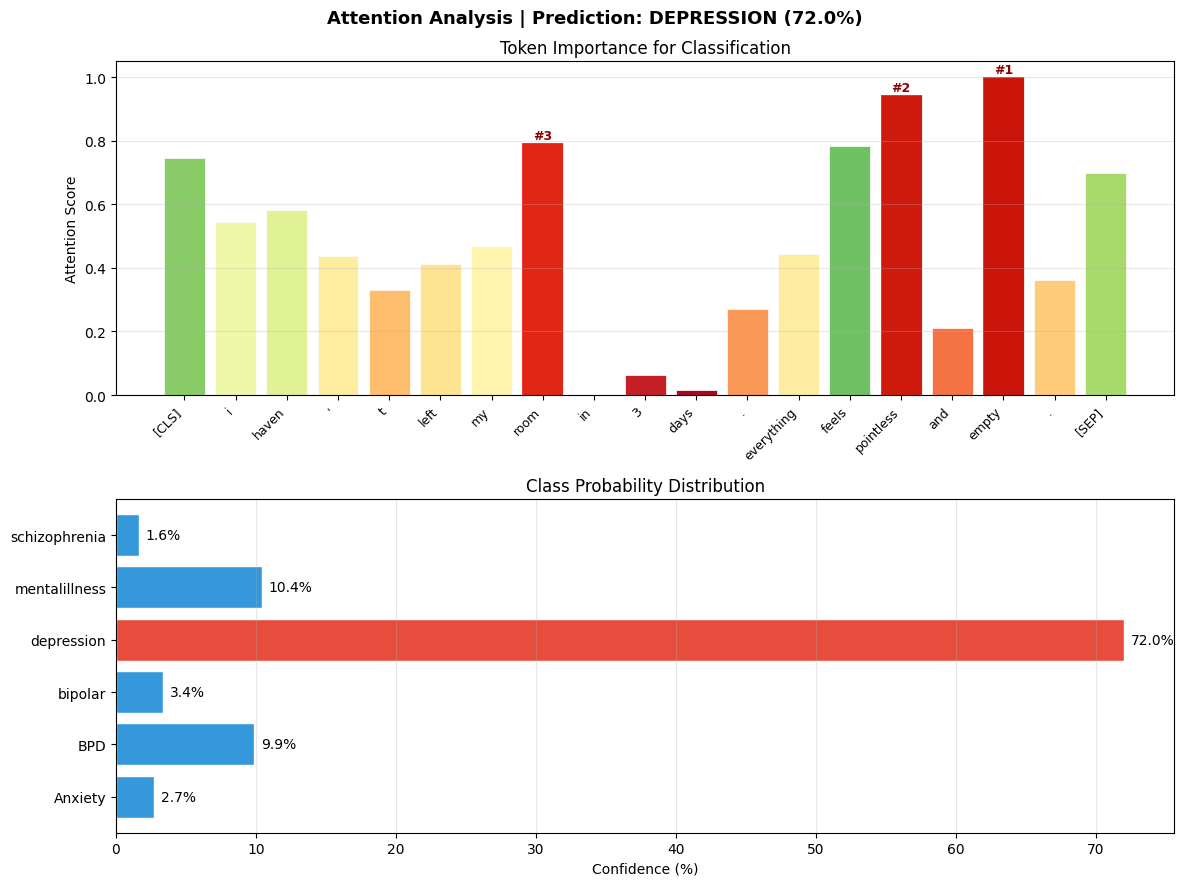

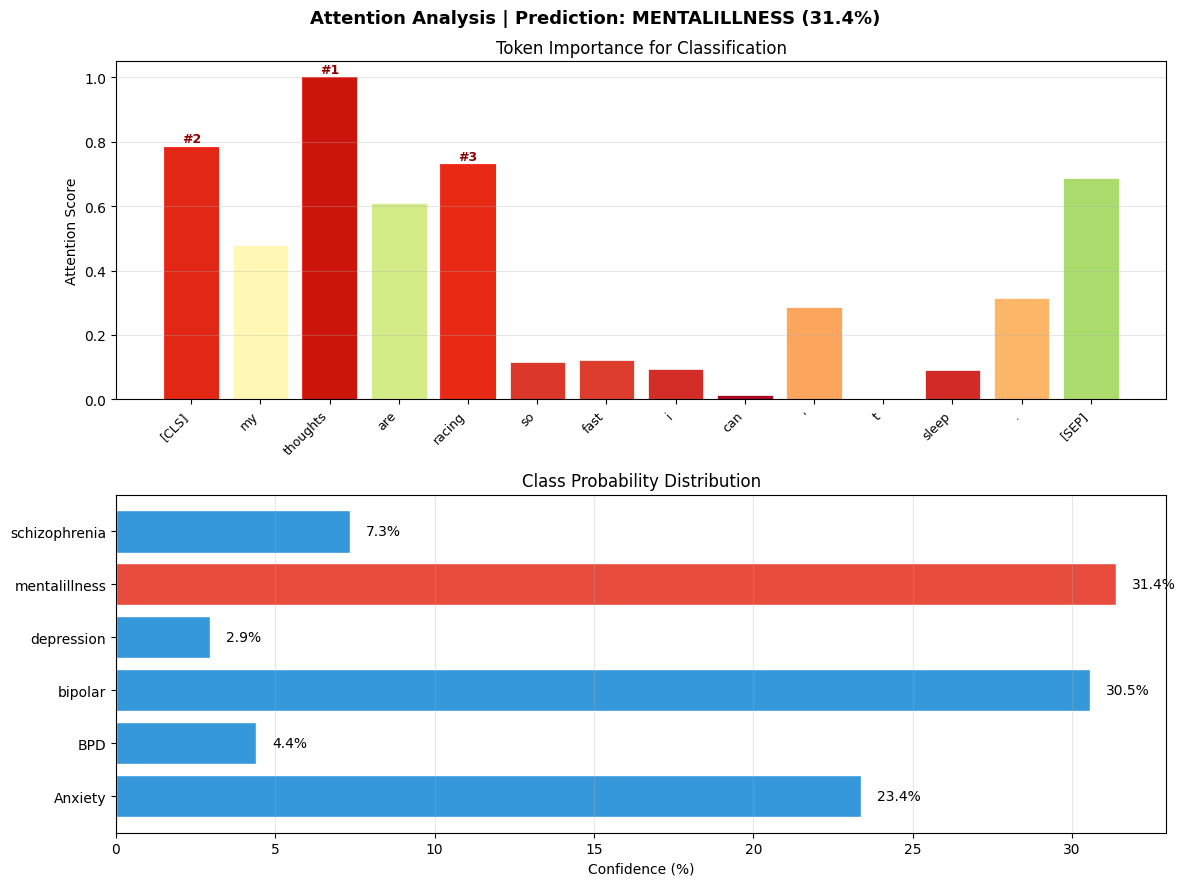

In [ ]:
best_model_attn = DistilBertForSequenceClassification.from_pretrained(
    f'{SAVE_PATH}/best_model',
    attn_implementation='eager'
)
best_model_attn.to(device)
best_model_attn.eval()
print('Best model loaded with eager attention backend.')

def visualize_attention(text, model, tokenizer, device, label_encoder, layer_idx=5, save_path=None):
    model.eval()
    clean  = clean_text(text)
    inputs = tokenizer(clean, return_tensors='pt', max_length=128, truncation=True, padding=False)
    tokens = [t.replace('##', '') for t in tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])]

    input_ids      = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)

    probs      = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
    pred_idx   = probs.argmax()
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    cls_attention = outputs.attentions[layer_idx].squeeze(0)[:, 0, :].mean(0).cpu().numpy()
    cls_norm = (cls_attention - cls_attention.min()) / (cls_attention.max() - cls_attention.min() + 1e-8)

    fig, axes = plt.subplots(2, 1, figsize=(max(12, len(tokens) * 0.6), 9))
    fig.suptitle(f'Attention Analysis | Prediction: {pred_label.upper()} ({probs[pred_idx]*100:.1f}%)',
                 fontsize=13, fontweight='bold')

    ax1 = axes[0]
    ax1.bar(range(len(tokens)), cls_norm, color=plt.cm.RdYlGn(cls_norm), edgecolor='white', linewidth=0.5)
    top3 = cls_norm.argsort()[-3:][::-1]
    for idx in top3:
        ax1.bar(idx, cls_norm[idx], color='red', alpha=0.8)
        ax1.annotate(f'#{list(top3).index(idx)+1}', xy=(idx, cls_norm[idx]),
                     xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9,
                     fontweight='bold', color='darkred')
    ax1.set_xticks(range(len(tokens)))
    ax1.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Attention Score'); ax1.set_title('Token Importance for Classification')
    ax1.grid(axis='y', alpha=0.3)

    ax2 = axes[1]
    colors_bar = ['#e74c3c' if i == pred_idx else '#3498db' for i in range(len(label_encoder.classes_))]
    bars2 = ax2.barh(label_encoder.classes_, probs * 100, color=colors_bar, edgecolor='white')
    for bar, prob in zip(bars2, probs):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{prob*100:.1f}%', va='center', fontsize=10)
    ax2.set_xlabel('Confidence (%)'); ax2.set_title('Class Probability Distribution')
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

attention_texts = [
    "I haven't left my room in 3 days. Everything feels pointless and empty.",
    "My thoughts are racing so fast I can't sleep.",
]
for i, text in enumerate(attention_texts):
    visualize_attention(text, best_model_attn, tokenizer, device, le,
                        save_path=f'{SAVE_PATH}/attention_{i+1}.png')

## ⚖️ Step 15 — Ethical Analysis & Bias Detection

> For mental health AI, accuracy alone is not enough.
> A missed depression case (False Negative) is more dangerous than a false alarm (False Positive).
> We measure the False Negative Rate per class to identify where the model is most risky.

ETHICAL ANALYSIS — AI FOR MENTAL HEALTH

FALSE NEGATIVE RATE per class:
(Percentage of real cases the model MISSES)

  Anxiety              FNR: 16.4%  FPR: 5.2%  [MEDIUM]
  BPD                  FNR: 22.2%  FPR: 5.9%  [HIGH RISK]
  bipolar              FNR: 27.8%  FPR: 3.4%  [HIGH RISK]
  depression           FNR: 21.6%  FPR: 8.7%  [HIGH RISK]
  mentalillness        FNR: 45.1%  FPR: 6.9%  [HIGH RISK]
  schizophrenia        FNR: 33.3%  FPR: 1.8%  [HIGH RISK]
Ethical analysis saved: /content/mental_health_project/ethical_analysis.png


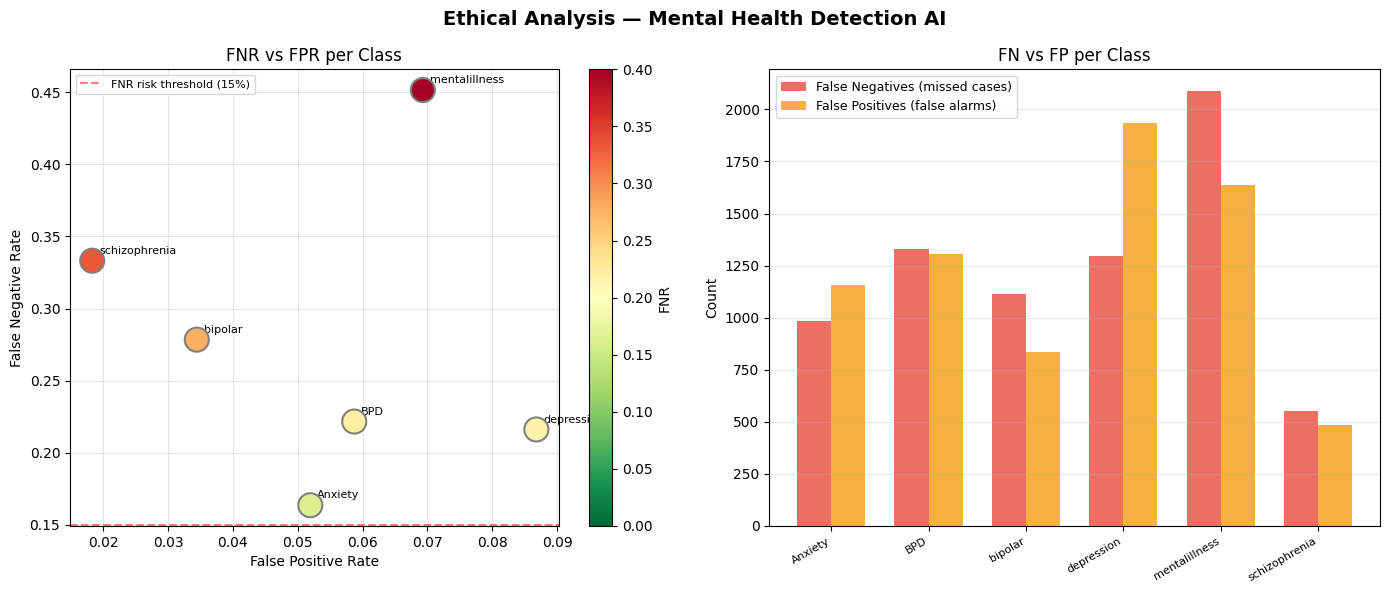

In [ ]:
def ethical_analysis(test_labels, test_preds, label_names, test_df, save_path=None):
    from sklearn.metrics import confusion_matrix
    print('=' * 60)
    print('ETHICAL ANALYSIS — AI FOR MENTAL HEALTH')
    print('=' * 60)

    cm = confusion_matrix(test_labels, test_preds)
    fnr_data = {}
    print('\nFALSE NEGATIVE RATE per class:')
    print('(Percentage of real cases the model MISSES)')
    print()
    for i, label in enumerate(label_names):
        tp  = cm[i, i]
        fn  = cm[i, :].sum() - tp
        fp  = cm[:, i].sum() - tp
        tn  = cm.sum() - tp - fn - fp
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr_data[label] = {'fnr': fnr, 'fpr': fpr, 'fn': fn, 'fp': fp}
        risk = 'HIGH RISK' if fnr > 0.2 else 'MEDIUM' if fnr > 0.1 else 'OK'
        print(f'  {label:<20} FNR: {fnr:.1%}  FPR: {fpr:.1%}  [{risk}]')

    labels_list = list(fnr_data.keys())
    fnrs = [fnr_data[l]['fnr'] for l in labels_list]
    fprs = [fnr_data[l]['fpr'] for l in labels_list]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Ethical Analysis — Mental Health Detection AI', fontsize=14, fontweight='bold')

    ax1 = axes[0]
    sc = ax1.scatter(fprs, fnrs, s=300, c=fnrs, cmap='RdYlGn_r', vmin=0, vmax=0.4,
                     edgecolors='gray', linewidth=1.5, zorder=5)
    for i, label in enumerate(labels_list):
        ax1.annotate(label, (fprs[i], fnrs[i]), xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax1.axhline(y=0.15, color='red', linestyle='--', alpha=0.5, label='FNR risk threshold (15%)')
    ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('False Negative Rate')
    ax1.set_title('FNR vs FPR per Class')
    ax1.legend(fontsize=8); plt.colorbar(sc, ax=ax1, label='FNR'); ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    fns = [fnr_data[l]['fn'] for l in labels_list]
    fps = [fnr_data[l]['fp'] for l in labels_list]
    x   = np.arange(len(labels_list)); w = 0.35
    ax2.bar(x-w/2, fns, w, label='False Negatives (missed cases)', color='#e74c3c', alpha=0.8)
    ax2.bar(x+w/2, fps, w, label='False Positives (false alarms)', color='#f39c12', alpha=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(labels_list, rotation=30, ha='right', fontsize=8)
    ax2.set_ylabel('Count'); ax2.set_title('FN vs FP per Class')
    ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Ethical analysis saved: {save_path}')
    plt.show()

ethical_analysis(
    test_labels, test_preds, label_names, test_df,
    save_path=f'{SAVE_PATH}/ethical_analysis.png'
)

## 🔬 Step 16 — Error Analysis

> Which classes does the model confuse most?
> Understanding errors helps explain model limitations.

ERROR ANALYSIS

Total errors: 7,361 of 28,277 (26.0%)

Top 10 most frequent class confusions:
True                 Predicted             Count
--------------------------------------------------
  mentalillness        → depression              777
  BPD                  → depression              492
  depression           → mentalillness           443
  mentalillness        → Anxiety                 418
  mentalillness        → BPD                     416
  BPD                  → mentalillness           368
  depression           → BPD                     368
  Anxiety              → depression              352
  depression           → Anxiety                 339
  Anxiety              → mentalillness           305
Error analysis saved: /content/mental_health_project/error_analysis.png


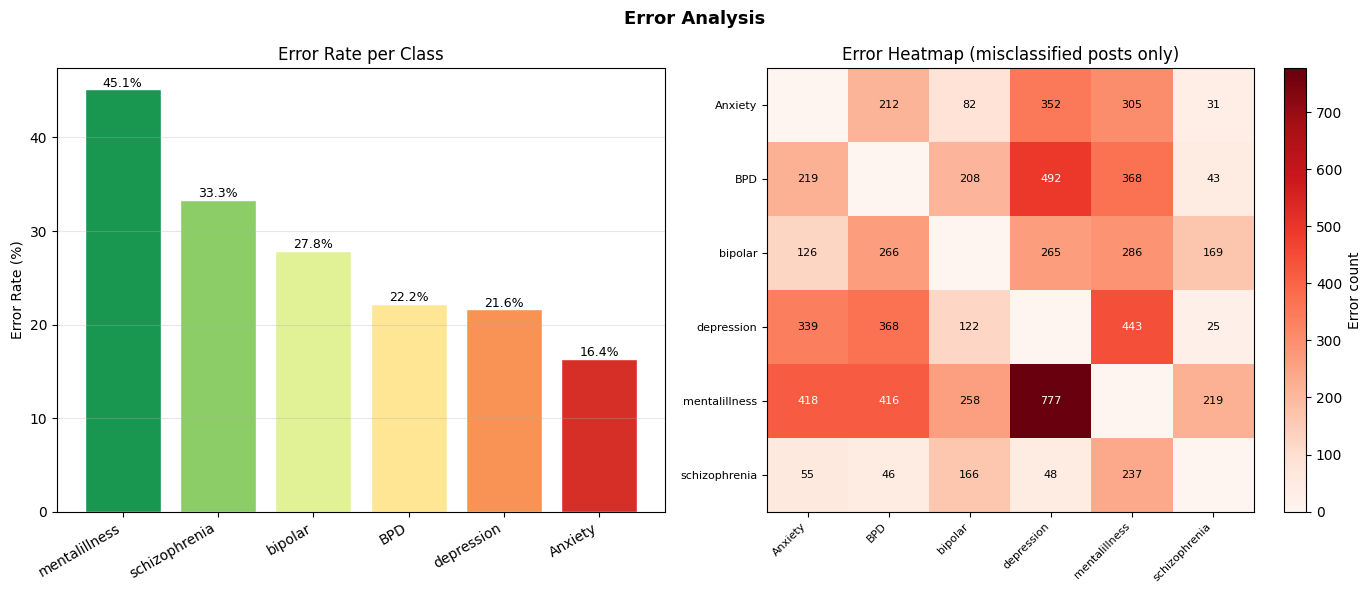

In [ ]:
def error_analysis(test_df, test_labels, test_preds, label_names, save_path=None):
    print('=' * 60)
    print('ERROR ANALYSIS')
    print('=' * 60)

    tdc = test_df.copy().reset_index(drop=True)
    tdc['true_label'] = [label_names[i] for i in test_labels]
    tdc['pred_label'] = [label_names[i] for i in test_preds]
    tdc['correct']    = tdc['true_label'] == tdc['pred_label']

    errors = tdc[~tdc['correct']].copy()
    print(f'\nTotal errors: {len(errors):,} of {len(tdc):,} ({len(errors)/len(tdc)*100:.1f}%)')

    confusion_pairs = errors.groupby(['true_label', 'pred_label']).size().sort_values(ascending=False).head(10)
    print('\nTop 10 most frequent class confusions:')
    print(f'{"True":<20} {"Predicted":<20} {"Count":>6}')
    print('-' * 50)
    for (true, pred), count in confusion_pairs.items():
        print(f'  {true:<20} → {pred:<20} {count:>6}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Error Analysis', fontsize=13, fontweight='bold')

    ax1 = axes[0]
    error_rate = tdc.groupby('true_label')['correct'].apply(lambda x: 1-x.mean()).sort_values(ascending=False)
    bars = ax1.bar(range(len(error_rate)), error_rate.values*100,
                   color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(error_rate))), edgecolor='white')
    ax1.set_xticks(range(len(error_rate))); ax1.set_xticklabels(error_rate.index, rotation=30, ha='right')
    ax1.set_ylabel('Error Rate (%)'); ax1.set_title('Error Rate per Class'); ax1.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, error_rate.values):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val*100:.1f}%', ha='center', fontsize=9)

    ax2 = axes[1]
    error_matrix = pd.crosstab(errors['true_label'], errors['pred_label']).reindex(
        index=label_names, columns=label_names, fill_value=0)
    im = ax2.imshow(error_matrix.values, cmap='Reds', aspect='auto')
    ax2.set_xticks(range(len(label_names))); ax2.set_yticks(range(len(label_names)))
    ax2.set_xticklabels(label_names, rotation=45, ha='right', fontsize=8)
    ax2.set_yticklabels(label_names, fontsize=8)
    ax2.set_title('Error Heatmap (misclassified posts only)')
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            v = int(error_matrix.values[i,j])
            if v > 0:
                ax2.text(j, i, str(v), ha='center', va='center', fontsize=8,
                         color='white' if v > error_matrix.values.max()*0.5 else 'black')
    plt.colorbar(im, ax=ax2, label='Error count')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Error analysis saved: {save_path}')
    plt.show()

error_analysis(
    test_df, test_labels, test_preds, label_names,
    save_path=f'{SAVE_PATH}/error_analysis.png'
)

## 💾 Step 17 — Save All Results

In [ ]:
from sklearn.metrics import classification_report

print('Saving all results...')
print()

with open(f'{SAVE_PATH}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('✓ Label encoder saved.')

report = classification_report(test_labels, test_preds, target_names=label_names)
with open(f'{SAVE_PATH}/classification_report.txt', 'w') as f:
    f.write(report)
print('✓ Classification report saved.')

pd.DataFrame(training_log).to_csv(f'{SAVE_PATH}/training_log.csv', index=False)
print('✓ Training log saved.')

pd.DataFrame({
    'true_label':      [label_names[i] for i in test_labels],
    'predicted_label': [label_names[i] for i in test_preds]
}).to_csv(f'{SAVE_PATH}/test_predictions.csv', index=False)
print('✓ Test predictions saved.')

# Experiment A results
pd.DataFrame([
    {'input': k, 'accuracy': v} for k, v in results_exp_a.items()
]).to_csv(f'{SAVE_PATH}/experiment_a_results.csv', index=False)
print('✓ Experiment A results saved.')

print(f'\nAll files in {SAVE_PATH}:')
for f in sorted(os.listdir(SAVE_PATH)):
    fpath = f'{SAVE_PATH}/{f}'
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f'  {f:<45} {size:.1f} KB')

# Download everything as zip
from google.colab import files
import shutil
shutil.make_archive('mental_health_results', 'zip', SAVE_PATH)
files.download('mental_health_results.zip')
print('\n✅ Results downloaded!')

Saving all results...

✓ Label encoder saved.
✓ Classification report saved.
✓ Training log saved.
✓ Test predictions saved.
✓ Experiment A results saved.

All files in /content/mental_health_project:
  attention_1.png                               108.4 KB
  attention_2.png                               101.0 KB
  classification_report.txt                     0.5 KB
  clustering_umap.png                           652.3 KB
  confusion_matrix.png                          103.8 KB
  error_analysis.png                            126.1 KB
  ethical_analysis.png                          130.5 KB
  experiment_a_results.csv                      0.1 KB
  label_encoder.pkl                             0.3 KB
  learning_curves.png                           80.8 KB
  test_predictions.csv                          502.7 KB
  training_log.csv                              0.1 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Results downloaded!


## 🏆 Step 18 — Final Project Summary

In [ ]:
best_val    = max(training_log, key=lambda x: x['val_acc'])
improvement = best_val['val_acc'] - baseline_results['val_acc']
best_exp_a  = max(results_exp_a, key=results_exp_a.get)

print('=' * 65)
print('FINAL PROJECT SUMMARY')
print('=' * 65)
print()
print('MODEL RESULTS:')
print(f'  {"Model":<35} {"Val Acc":>10} {"Test Acc":>10} {"Parameters":>12}')
print('  ' + '-' * 63)
print(f'  {"TF-IDF + Logistic Regression":<35} '
      f'{baseline_results["val_acc"]:>10.4f} '
      f'{baseline_results["test_acc"]:>10.4f} '
      f'{"—":>12}')
print(f'  {"DistilBERT (fine-tuned)":<35} '
      f'{best_val["val_acc"]:>10.4f} '
      f'{"(see test)":>10} '
      f'{"66M":>12}')
print('  ' + '-' * 63)
print(f'  DistilBERT improvement: +{improvement:.4f} ({improvement*100:.1f} pp over baseline)')
print()
print('EXPERIMENT A — INPUT COMPARISON (DistilBERT):')
for name, acc in results_exp_a.items():
    marker = ' ← BEST' if name == best_exp_a else ''
    print(f'  {name:<30} {acc:.4f}{marker}')
print()
print('TRAINING LOG:')
for entry in training_log:
    print(f'  Epoch {entry["epoch"]}: Loss={entry["train_loss"]} | '
          f'Train={entry["train_acc"]} | Val={entry["val_acc"]}')
print()
print('COMPLETED COMPONENTS:')
print('  ✓ Data loading, cleaning and balancing (80k/class)')
print('  ✓ DistilBERT fine-tuning (main model)')
print('  ✓ Baseline comparison (TF-IDF + Logistic Regression)')
print('  ✓ Experiment A: Input comparison using trained DistilBERT')
print('  ✓ Experiment B: Clustering on DistilBERT embeddings (K-Means + UMAP)')
print('  ✓ Learning curves and model comparison')
print('  ✓ Confusion matrix and classification report')
print('  ✓ Prediction system with confidence scores')
print('  ✓ Attention visualization (Explainable AI)')
print('  ✓ Ethical analysis and bias detection')
print('  ✓ Error analysis')
print(f'\nAll outputs saved to: {SAVE_PATH}')

FINAL PROJECT SUMMARY

MODEL RESULTS:
  Model                                  Val Acc   Test Acc   Parameters
  ---------------------------------------------------------------
  TF-IDF + Logistic Regression            0.7193     0.7219            —
  DistilBERT (fine-tuned)                 0.7386 (see test)          66M
  ---------------------------------------------------------------
  DistilBERT improvement: +0.0193 (1.9 pp over baseline)

EXPERIMENT A — INPUT COMPARISON (DistilBERT):
  Title only                     0.4462
  Body only                      0.6626
  Combined                       0.7397 ← BEST

TRAINING LOG:
  Epoch 1: Loss=0.9669 | Train=0.6496 | Val=0.7235
  Epoch 2: Loss=0.7501 | Train=0.7363 | Val=0.734
  Epoch 3: Loss=0.6832 | Train=0.7609 | Val=0.7385
  Epoch 4: Loss=0.6377 | Train=0.7784 | Val=0.7386

COMPLETED COMPONENTS:
  ✓ Data loading, cleaning and balancing (80k/class)
  ✓ DistilBERT fine-tuning (main model)
  ✓ Baseline comparison (TF-IDF + Logistic Reg